## Final Project - Nonlinear Modeling

##### Intro to Deep Learning & PyTorch

###### week11practice.ipynb
- Basic datatype
- creating tensors
- operation examples
- tensor to/from a NumPy array
- torch.device("cuda") --> tensor on GPU
- automatic differentiation & gradients
- perceptron & MLP
    - forward propogation
    - [(nonlinear) activation functions](https://docs.pytorch.org/docs/stable/nn.functional.html) (sigmoid, hyperbolic tangent, ReLU)
    - shallow (single-layer) vs. deep (multi-layer) NN

###### week11-2.ipynb
- loss function
    - mean square error: continuous regression (response) task  
    - binary cross entropy: binary classification
- [Training algorithms](https://docs.pytorch.org/docs/stable/optim.html)
    - [Gradient descent](https://www.geeksforgeeks.org/machine-learning/gradient-descent-algorithm-and-its-variants/): general algorithm; computes gradient for each data point
    - alternative algorithms
        - stochastic GD: only one training example is used to compute the gradient and update the parameters at each iteration
            - can be faster than batch gradient descent but may lead to more noise in the updates
        - mini-batch GD: a small batch of training examples is used to compute the gradient and update the parameters at each iteration
            - can be a good compromise; can be faster than GD and less noisy than Stochastic GD
        - Momentum-based GD
        - Nesterov Accelerated Gradient (NAG)
        - Adagrad
        - RMSProp
        - Adam
    - backpropogation
    - learning rate
        - small: converges slowly and gets stuck at false local minima
        - large:  overshoots, becomes unstable, and diverges
        - choosing
            - trial-and-error
            - adaptive learning rate

##### week12-1.ipynb
- stochastic with mini-batches
    - Loading & Batching Data (DataLoader) in PyTorch
- Regulation
    - Reducing overfitting (regularization)
        - [dropout](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.dropout.html): randomly set some activation to 0
            - won't rely on particular connections too heavily; will consider more connections
            - weight values will be more spread out
        - early stopping
            - decompose into training, validation, and test data
            - stop if: (test loss decreases) or (validation loss stops decreasing up to some threshold)


#### Setup

I will ultimately fit my final fitted MLP model. Pytorch enables me to use a GPU for parallelizable computational efficiency gains. Without access to this device, the file will stop and discontinue further training.

In [ ]:
# Hard stop if GPU is unavailable
import torch


if not torch.cuda.is_available():
    raise RuntimeError(
        "ERROR: A GPU is required to run this script.\n"
        "Go to Runtime → Change runtime type → Hardware accelerator → GPU."
    )

device = torch.device("cuda")
print(f"GPU is available and set to {device}.")

GPU is available and set to cuda.


In [ ]:
# Remaining imports and reproducibility settings
import os
import random
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from copy import deepcopy
import time
from google.colab import drive
import matplotlib.pyplot as plt

# global seeds for reproducibility; set locally below too
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed) # for all devices
torch.cuda.manual_seed_all(seed) # for GPU device

# make cuDNN choose deterministic kernels (possibly slower but reproducible)
    # cudNNN: NVIDIA CUDA Deep Neural Network library
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# Google Drive Mount & File Directory
drive.mount('/content/drive')

os.chdir("/content/drive/My Drive/Colab Notebooks/Project") # change to your directory
print("Working directory:", os.getcwd())
print("Directory contents:", os.listdir())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/My Drive/Colab Notebooks/Project
Directory contents: ['proposal_guideline.pdf', 'Final_project_guideline.pdf', 'austin_micromobility_metadata.txt', 'austin_micromobility.csv', 'LossMLP.png', 'ProjectProposal.pdf', '.Rhistory', 'ProjectScript1.ipynb', 'ProjectScript2.ipynb', 'ProjectScript3.ipynb', 'ProjectProposalSubmission.pdf', 'Heatmap.png', 'train_data.csv', 'val_data.csv', 'test_data.csv', 'DataManipulation.ipynb', 'PerceptronLoss.png', 'LinearModeling.ipynb', 'NonLinearModeling.ipynb', 'FinalMLP.ipynb']


#### Load Data & Preprocess


In [ ]:
# Load data
train_df = pd.read_csv("train_data.csv")
val_df   = pd.read_csv("val_data.csv")
test_df  = pd.read_csv("test_data.csv")

X_train, y_train = train_df.drop(columns=['_log_trip_distance']), train_df['_log_trip_distance']
X_val,   y_val   = val_df.drop(columns=['_log_trip_distance']),   val_df['_log_trip_distance']
X_test,  y_test  = test_df.drop(columns=['_log_trip_distance']),  test_df['_log_trip_distance']

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val   = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
X_test  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

# Convert to Tensors
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
X_val_t   = torch.tensor(X_val.values,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test.values,  dtype=torch.float32)

y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_t   = torch.tensor(y_val.values,   dtype=torch.float32).view(-1, 1)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).view(-1, 1)

print("Tensors created on CPU. They will be moved to GPU batch-by-batch during training.")

Train: (1026295, 10) (1026295,)
Validation: (219920, 10) (219920,)
Test: (219921, 10) (219921,)
Tensors created on CPU. They will be moved to GPU batch-by-batch during training.


In [ ]:
# Reproducible generator for DataLoader shuffling
g = torch.Generator().manual_seed(seed)

# DataLoaders
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=8192,
    shuffle=True,
    generator=g       # fixed RNG; deterministic shuffling
)

for attr, value in train_loader.__dict__.items():
    print(f"{attr}: {value}")

print("\n")

val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=8192,
    shuffle=False     # no shuffling for validation/test sets
)

for attr, value in val_loader.__dict__.items():
    print(f"{attr}: {value}")

dataset: <torch.utils.data.dataset.TensorDataset object at 0x7ccb17c4ab10>
num_workers: 0
prefetch_factor: None
pin_memory: False
pin_memory_device: 
timeout: 0
worker_init_fn: None
_DataLoader__multiprocessing_context: None
in_order: True
_dataset_kind: 0
batch_size: 8192
drop_last: False
sampler: <torch.utils.data.sampler.RandomSampler object at 0x7ccb17c4ab70>
batch_sampler: <torch.utils.data.sampler.BatchSampler object at 0x7ccb17c49520>
generator: <torch._C.Generator object at 0x7ccc5c67afd0>
collate_fn: <function default_collate at 0x7ccb8abb51c0>
persistent_workers: False
_DataLoader__initialized: True
_IterableDataset_len_called: None
_iterator: None


dataset: <torch.utils.data.dataset.TensorDataset object at 0x7ccb17c4b110>
num_workers: 0
prefetch_factor: None
pin_memory: False
pin_memory_device: 
timeout: 0
worker_init_fn: None
_DataLoader__multiprocessing_context: None
in_order: True
_dataset_kind: 0
batch_size: 8192
drop_last: False
sampler: <torch.utils.data.sampler.Seque

#### Model Fitting

Mini-batch gradient descent introduces more stochastic variation in the validation loss, so very small improvements (e.g. 1e-4) often reflect noise rather than true learning progress. Increasing `min_delta` to 1e-3 makes early stopping more sensitive to meaningful improvements while still preventing premature stopping, especially when predictive performance is the primary goal. Keeping patience at 5 preserves a small buffer against random fluctuations while ensuring the model does not over-train.

In [ ]:
class FinalMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

# Set seed BEFORE model init for reproducible weights
torch.manual_seed(seed)
model = FinalMLP(input_dim=X_train_t.shape[1]).to(device)
print(model)

FinalMLP(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
# Early stopping
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-3):
        self.patience = patience
        self.min_delta = min_delta
        self.best = float("inf")
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best - self.min_delta:
            self.best = val_loss
            self.counter = 0
            self.best_state = deepcopy(model.state_dict())
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

In [ ]:
# training loop; includes early stopping and best model restoration
    # move batches to GPU during training/validation
def train_final_model(model, max_epochs=100, lr=0.01):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    es = EarlyStopping(patience=5, min_delta=1e-3)

    train_hist, val_hist = [], []
    start = time.perf_counter()

    for epoch in range(1, max_epochs + 1):

        # ---- TRAIN ----
        model.train()
        train_loss_epoch = 0.0

        for xb_cpu, yb_cpu in train_loader:
            # move current batch to GPU
            xb = xb_cpu.to(device)
            yb = yb_cpu.to(device)

            optimizer.zero_grad()
            preds = model(xb).squeeze()
            loss = criterion(preds, yb.squeeze())
            loss.backward()
            optimizer.step()
            train_loss_epoch += loss.item()

        train_loss_epoch /= len(train_loader)
        train_hist.append(train_loss_epoch)

        # ---- VALIDATE (full batch on GPU) ----
        model.eval()
        with torch.no_grad():
            Xv = X_val_t.to(device)
            yv = y_val_t.to(device)
            preds_val = model(Xv).squeeze()
            val_loss = criterion(preds_val, yv.squeeze()).item()

        val_hist.append(val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch}/{max_epochs} | Train={train_loss_epoch:.4f} | Val={val_loss:.4f}")

        if es.step(val_loss, model):
            print(f"\nEarly stopping at epoch {epoch}. Best val={es.best:.4f}")
            break

    # Restore best model
    model.load_state_dict(es.best_state)

    elapsed = time.perf_counter() - start
    print(f"\nTraining completed in {elapsed:.2f} seconds.")

    return model, train_hist, val_hist

In [ ]:
# Train final model
model_gpu, train_hist, val_hist = train_final_model(
    model,
    max_epochs=100,
    lr=0.01
)

Epoch 1/100 | Train=6.5562 | Val=1.7899
Epoch 10/100 | Train=0.8682 | Val=0.8631
Epoch 20/100 | Train=0.7398 | Val=0.7370
Epoch 30/100 | Train=0.7228 | Val=0.7423
Epoch 40/100 | Train=0.6912 | Val=0.7145

Early stopping at epoch 44. Best val=0.6886

Training completed in 478.31 seconds.


In [ ]:
# Final test evaluation
model_gpu.eval()
criterion = nn.MSELoss()

with torch.no_grad():
    Xt = X_test_t.to(device)
    yt = y_test_t.to(device)
    preds_test = model_gpu(Xt).squeeze()
    test_mse = criterion(preds_test, yt.squeeze()).item()

print(f"\nFinal Test MSE (log-scale): {test_mse:.4f}")


Final Test MSE (log-scale): 0.7178


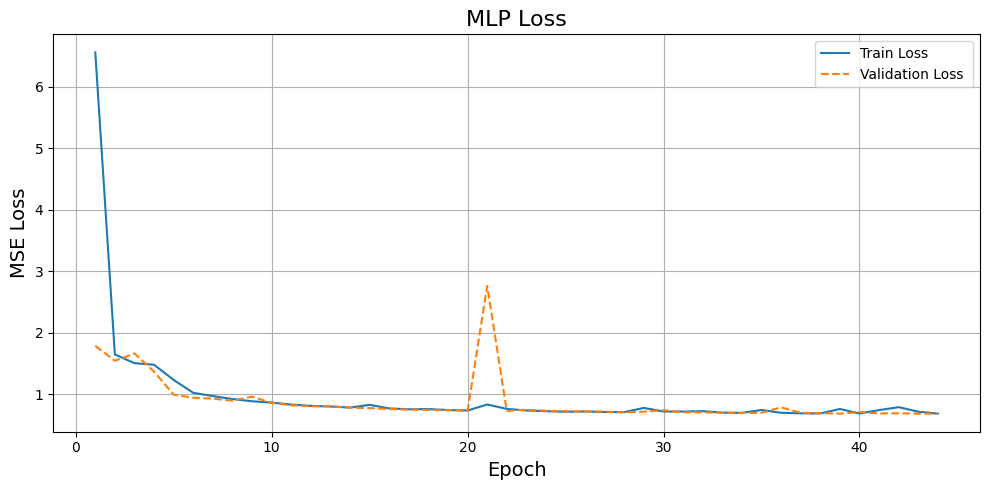

In [ ]:
# plot best MLP training and validation loss curves for dropout p=0.0
epochs = range(1, len(train_hist) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_hist, label="Train Loss")
plt.plot(epochs, val_hist, label="Validation Loss ", linestyle='dashed')
plt.xlabel("Epoch", fontsize=14); plt.ylabel("MSE Loss", fontsize=14)
plt.title("MLP Loss", fontsize=16)
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()